In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_lorenz(n_steps, dt=0.01, warmup=1000):
    def lorenz(state, sigma=10, rho=28, beta=8/3):
        x, y, z = state
        return np.array([sigma*(y-x), x*(rho-z)-y, x*y-beta*z])
    
    states = np.zeros((3, n_steps + warmup))
    states[:, 0] = [1, 1, 1]
    
    for i in range(n_steps + warmup - 1):
        k1 = lorenz(states[:, i])
        k2 = lorenz(states[:, i] + dt/2 * k1)
        k3 = lorenz(states[:, i] + dt/2 * k2)
        k4 = lorenz(states[:, i] + dt * k3)
        states[:, i+1] = states[:, i] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    
    return states[:, warmup:]

data = generate_lorenz(10000)

# Basic ESN Prediction on Lorenz Attractor

Train an Echo State Network to learn the Lorenz system dynamics, then generate autonomous predictions.

**Data preparation:**
- Generate 100k steps of Lorenz trajectory
- Downsample by factor of 5 → effective dt = 0.05

**ESN configuration:**
- `N=1500`: Large reservoir for complex dynamics
- `spectral_radius=0.1`: Low value, very stable/fading memory
- `sparsity=0.99`: Only 1% of reservoir connections are non-zero

**Training:**
- Uses full dataset with 1000 step washout to forget initial transient

**Prediction:**
- Warm up reservoir with data from step 7800 onward
- Generate 5000 autonomous steps (no external input, feeds own predictions back)

In [3]:
from rc import ESN

data = generate_lorenz(100000)  
data = data[:, ::5] 

In [4]:
# esn without explicit config
esn = ESN(N=1500, input_dim=3, spectral_radius=0.1, sparsity=0.99)

# train esn 
states_train = esn.train(data[:, :], washout=1000, return_states=True)

In [5]:
# predict
predictions, states_autonomous = esn.predict(warmup=data[:, 7800:], steps=5000)

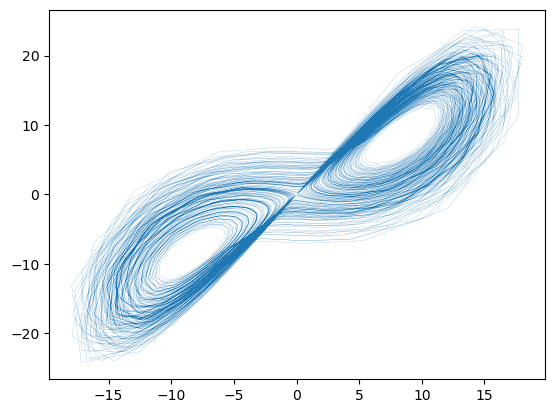

In [6]:
plt.plot(predictions[0, :], predictions[1, :], linewidth=0.1)

In [7]:
from rc import analyse_dynamics
import plotly.graph_objects as go

res = analyse_dynamics(states_train)
print(f"Effective dimension of RC during training: {res['effective_dim']}")
res_autonomous = analyse_dynamics(states_autonomous)
print(f"Effective dimension of RC during autonomous prediction: {res_autonomous['effective_dim']}")

fig = go.Figure(data=[
    go.Scatter3d(
        x=res['pca_scores'][:, 0],
        y=res['pca_scores'][:, 1],
        z=res['pca_scores'][:, 2],
        mode='lines',
        line=dict(width=1),
        name='Training',
        opacity=0.6
    ),
    go.Scatter3d(
        x=res_autonomous['pca_scores'][:, 0],
        y=res_autonomous['pca_scores'][:, 1],
        z=res_autonomous['pca_scores'][:, 2],
        mode='lines',
        line=dict(width=1),
        name='Autonomous',
        opacity=0.6
    )
])
fig.show()


Effective dimension of RC during training: 2.2725468657906265
Effective dimension of RC during autonomous prediction: 2.2706759687052886


# ESN with Explicit Configuration

Using `ESNConfig` for full control over hyperparameters. Useful for reproducibility and hyperparameter sweeps.

**Configuration parameters:**
- `N=500`: Reservoir size (number of neurons)
- `input_dim=3`: Matches Lorenz system (x, y, z)
- `spectral_radius=0.9`: Near edge of stability, good for chaotic systems
- `alpha=1e-6`: Ridge regression regularization (prevents overfitting)
- `sparsity=0.95`: 95% of reservoir weights are zero (sparse connectivity)
- `input_scaling=0.5`: Scale input weights to control input influence
- `seed=42`: Reproducible initialization

**Training:**
- First 8000 timesteps
- 200 step washout discards initial transient states

In [8]:
from rc import ESN, ESNConfig

config = ESNConfig(
    N=1500,
    input_dim=3,
    spectral_radius=0.9,
    alpha=1e-3,
    sparsity=0.99,
    input_scaling=0.5,
    bias_scaling=0.5,
    seed=42,
)

esn = ESN(config)
esn.train(data[:, :], washout=1000)

In [9]:
predictions, states = esn.predict(warmup=data[:, 7800:], steps=5000)

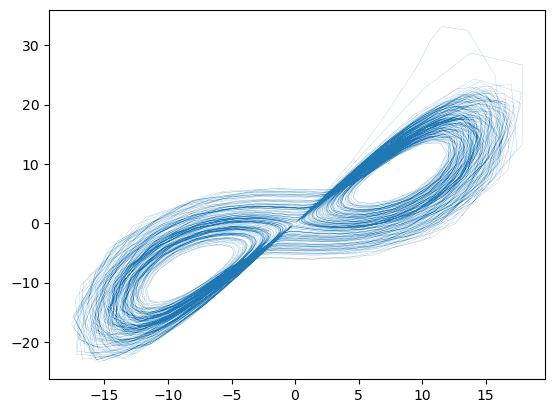

In [10]:
plt.plot(predictions[0, :], predictions[1, :], linewidth=0.1)

# Reservoir Dynamics Modes

Different update rules for reservoir state. Each creates different memory and nonlinearity characteristics.

**Standard** (default)
$$r_{t+1} = \tanh(W_r r_t + W_x x_t + b)$$
Classic ESN. Full state replacement each step.

**Leaky Integrator**
$$r_{t+1} = (1 - \alpha) r_t + \alpha \tanh(W_r r_t + W_x x_t + b)$$
Exponential moving average of states. `leaky_rate=0.3` means 30% new, 70% old. Smoother dynamics, longer memory.

**Leaky Random** (`leakyrand`)
Same as leaky, but each neuron gets a different rate sampled from `[leaky_rate - scale, leaky_rate + scale]`. Heterogeneous timescales → richer dynamics.

**ES2N**
$$r_{t+1} = \beta \tanh(W_r r_t + W_x x_t + b) + (1 - \beta)(O \cdot r_t)$$
Mixes nonlinear update with orthogonal rotation of previous state. `beta=0.7` means 70% nonlinear, 30% linear rotation. Can improve gradient flow and memory.

In [13]:
# standard (default)
esn = ESN(N=500, input_dim=3, mode='standard')

# leaky integrator
esn = ESN(N=500, input_dim=3, mode='leaky', leaky_rate=0.3)

# leaky with random per-neuron rates
esn = ESN(N=500, input_dim=3, mode='leakyrand', leaky_rate=0.3, scale=0.1)

# ES2N
esn = ESN(N=500, input_dim=3, mode='es2n', beta=0.7)

# Manual Dynamics with Heterogeneous Leaky Rates

Create custom per-neuron leaky rates for richer temporal dynamics. Different neurons integrate at different timescales.

This bypasses the `mode='leakyrand'` shortcut when you need precise control over the distribution.

In [11]:
from rc import ESN, ESNConfig, LeakyDynamics

N = 1500
rng = np.random.default_rng(42)

leaky_rates = rng.uniform(0.1, 0.5, N)
dynamics = LeakyDynamics(leaky_rate=leaky_rates)

config = ESNConfig(N=N, input_dim=3, spectral_radius=0.9, seed=42, sparsity=0.99)
esn = ESN(config, dynamics=dynamics)

In [12]:
esn.train(data[:, :], washout=1000)

In [13]:
predictions, states = esn.predict(warmup=data[:, 7800:], steps=5000)

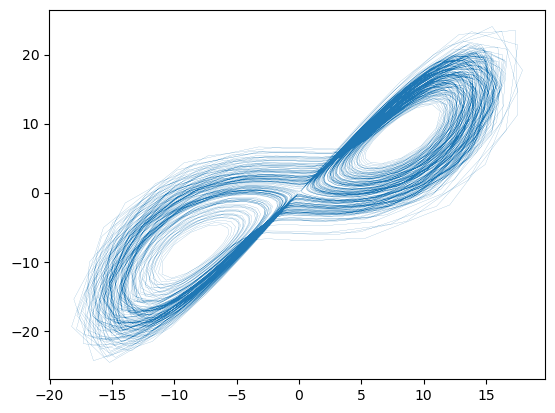

In [14]:
plt.plot(predictions[0, :], predictions[1, :], linewidth=0.1)

# Save and Load Model

Serialize trained ESN to disk. Saves all weights, config, dynamics parameters, and reservoir state.

In [68]:
# save
esn.save('my_model.npz')

In [69]:
# load
esn_loaded = ESN.load('my_model.npz')
predictions, _ = esn_loaded.predict(data[:, 7800:], steps=500)

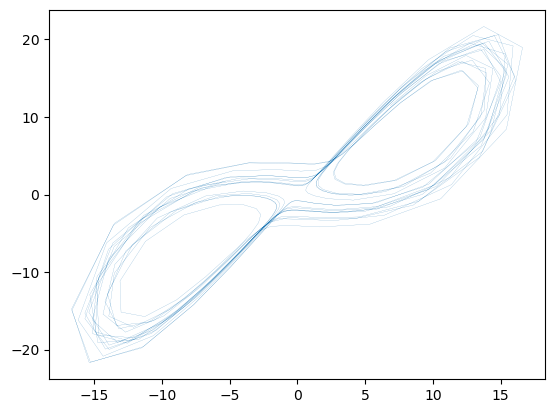

In [70]:
plt.plot(predictions[0, :], predictions[1, :], linewidth=0.1)

# Lyapunov Spectrum of Trained ESN

Compute Lyapunov exponents of the autonomous (free-running) ESN dynamics. Measures chaos in the learned system.

**Parameters:**
- `initial_data`: used to initialize reservoir state before autonomous run
- `num_lyaps`: number of exponents to compute (largest first)
- `steps`: autonomous prediction steps for estimation
- `norm_time`: QR renormalization interval (numerical stability)
- `dt`: timestep for continuous-time conversion 
- `num_samples`: independent runs for statistics
- `warmup`: steps to drive reservoir before measurement starts
- `transient`: additional steps for tangent vectors to align with Lyapunov directions

**Interpretation:**
- Positive exponents → chaos (exponential divergence of nearby trajectories)
- Zero exponent → neutral (present in continuous-time autonomous systems)
- Negative exponents → contraction

True Lorenz has exponents ≈ (0.9, 0, −14.6)

Max LE: 0.9095
Spectrum: [ 9.09472758e-01 -7.23908137e-03 -1.89985815e+01 -3.17235420e+01
 -4.89330273e+01]


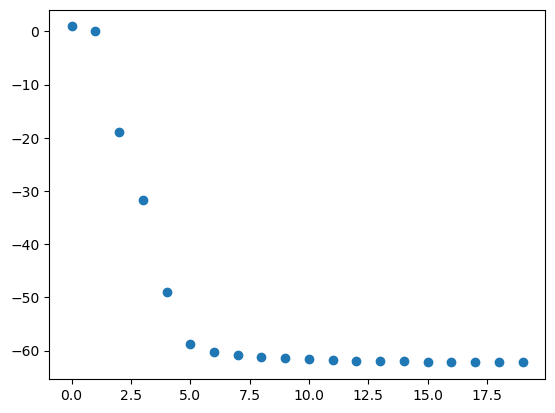

In [16]:
esn = ESN(N=1500, input_dim=3, spectral_radius=0.1, sparsity=0.99)
esn.train(data[:, :], washout=1000)
result = esn.lyapunov_spectrum(
    initial_data=data[:, :],
    num_lyaps=20,
    steps=5000,
    norm_time=10,
    dt=0.05,  
    num_samples=3,
    warmup=1000,
    transient=500,
)
plt.plot(result['mean'], 'o')
print(f"Max LE: {result['max_lyapunov']:.4f}")
print(f"Spectrum: {result['mean'][:5]}")

# Conditional Lyapunov Exponents (CLE)

Measure reservoir stability when **driven by external data** (not free-running).

**Key difference from Lyapunov spectrum:**
- LE: autonomous ESN dynamics (feeds own predictions)
- CLE: driven dynamics (receives external input)

**Parameters:**
- `data`: driving time series (must be long enough for warmup + transient + measurement)
- `warmup`: steps to drive reservoir before measurement starts
- `transient`: additional steps for tangent vectors to align with Lyapunov directions

**Interpretation:**
- **Negative max CLE** → reservoir synchronizes to input → good for prediction (echo state property)
- **Positive max CLE** → reservoir is chaotic even when driven → unreliable predictions

This is how you verify the echo state property holds for your configuration.

In [17]:
result = esn.conditional_lyapunov_spectrum(
    data=data[:, :10000],  
    num_lyaps=1,
    norm_time=10,
    dt=0.05,
    warmup=1000,
    transient=1500,
)


Max CLE: -76.9636


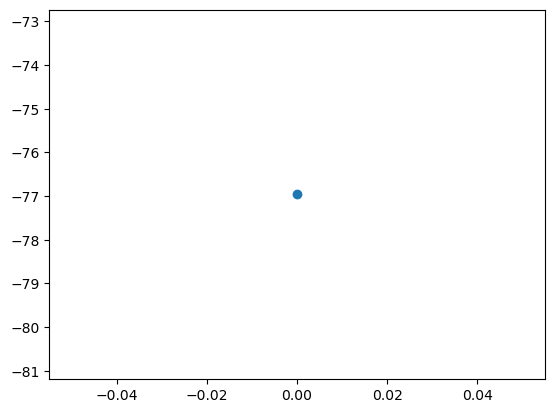

In [18]:
plt.plot(result['exponents'], 'o')
print(f"Max CLE: {result['max_cle']:.4f}")
